In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print(pd.options.display.max_rows)

60


In [4]:
pd.options.display.max_rows = len(x)

In [21]:
y = pd.read_csv("C:/Users/hp/Downloads/choclate_project analysis.csv")
x = pd.DataFrame(y)
y

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %
0,Ram Mahesh,New Zealand,70% Dark Bites,"$1,624",114,14,"1,652",($28),-2%
1,Brien Boise,USA,Choco Coated Almonds,"$6,706",459,9,"3,970","$2,736",41%
2,Husein Augar,USA,Almond Choco,$959,147,12,"1,746",($787),-82%
3,Carla Molina,Canada,Drinking Coco,"$9,632",288,6,"1,863","$7,769",81%
4,Curtice Advani,UK,White Choc,"$2,100",414,13,"5,444","($3,344)",-159%
5,Ram Mahesh,USA,Peanut Butter Cubes,"$8,869",432,12,"5,344","$3,525",40%
6,Curtice Advani,Australia,Smooth Sliky Salty,"$2,681",54,6,313,"$2,368",88%
7,Brien Boise,USA,After Nines,"$5,012",210,10,"2,052","$2,960",59%
8,Ches Bonnell,Australia,50% Dark Bites,"$1,281",75,12,878,$404,31%
9,Gigi Bohling,New Zealand,50% Dark Bites,"$4,991",12,12,140,"$4,851",97%


In [8]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   300 non-null    object
 1   Geography      300 non-null    object
 2   Product        300 non-null    object
 3   Amount         300 non-null    object
 4   Units          300 non-null    int64 
 5   cost per unit  300 non-null    int64 
 6   Cost           300 non-null    object
 7   Profit         300 non-null    object
 8   profit %       300 non-null    object
dtypes: int64(2), object(7)
memory usage: 21.2+ KB


In [10]:
x.describe()

,Units,cost per unit
count,300.000000,300.000000
mean,152.200000,9.473333
std,118.099499,3.457717
min,0.000000,3.000000
25%,54.000000,6.000000
50%,124.500000,9.000000
75%,220.500000,12.000000
max,525.000000,17.000000


In [12]:
x.dtypes

Sales Person     object
Geography        object
Product          object
Amount           object
Units             int64
cost per unit     int64
Cost             object
Profit           object
profit %         object
dtype: object

# CLEANING.

In [13]:
#checking duplicates
x.duplicated().sum()

0

In [24]:
#checking for null values
x.isnull().sum()

Sales Person     0
Geography        0
Product          0
Amount           0
Units            0
cost per unit    0
Cost             0
Profit           0
profit %         0
dtype: int64

In [23]:
#replace '#DIV/0!' with '0'
x["profit %"]=x["profit %"].str.replace('#DIV/0!','0%')

In [26]:
#CONVERTING STRINGS TO INT 'AMOUNT'
x['Amount'] = x['Amount'].replace(r'[\$,]', '', regex=True).astype(np.int64)

In [27]:
x.head()

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %
0,Ram Mahesh,New Zealand,70% Dark Bites,1624,114,14,"1,652",($28),-2%
1,Brien Boise,USA,Choco Coated Almonds,6706,459,9,"3,970","$2,736",41%
2,Husein Augar,USA,Almond Choco,959,147,12,"1,746",($787),-82%
3,Carla Molina,Canada,Drinking Coco,9632,288,6,"1,863","$7,769",81%
4,Curtice Advani,UK,White Choc,2100,414,13,"5,444","($3,344)",-159%


In [30]:
#CONVERTING STRINGS TO INT 'Profit'
x['Profit'] = x['Profit'].replace(r'[\$,]', '', regex=True)
# removing parentheses
x["Profit"] = x["Profit"].str.replace(r'\((.*?)\)',r'-\1',regex= True)
x['Profit'] = x['Profit'].astype(np.int64)

In [31]:
x.head()

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %
0,Ram Mahesh,New Zealand,70% Dark Bites,1624,114,14,"1,652",-28,-2%
1,Brien Boise,USA,Choco Coated Almonds,6706,459,9,"3,970",2736,41%
2,Husein Augar,USA,Almond Choco,959,147,12,"1,746",-787,-82%
3,Carla Molina,Canada,Drinking Coco,9632,288,6,"1,863",7769,81%
4,Curtice Advani,UK,White Choc,2100,414,13,"5,444",-3344,-159%


# ANALYSIS.

In [32]:
#groupby geography
m=x.groupby('Geography')

In [64]:
m.get_group('New Zealand')

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %,Loss,Actual Profit
0,Ram Mahesh,New Zealand,70% Dark Bites,1624,114,14,"1,652",-28,-2%,28,0
9,Gigi Bohling,New Zealand,50% Dark Bites,4991,12,12,140,4851,97%,0,4851
11,Gunar Cockshoot,New Zealand,Eclairs,3983,144,3,448,3535,89%,0,3535
16,Curtice Advani,New Zealand,Smooth Sliky Salty,7693,87,6,504,7189,93%,0,7189
23,Brien Boise,New Zealand,99% Dark & Pure,1771,204,8,"1,559",212,12%,0,212
29,Oby Sorrel,New Zealand,Fruit & Nut Bars,4683,30,6,195,4488,96%,0,4488
30,Carla Molina,New Zealand,85% Dark Bars,6398,102,5,507,5891,92%,0,5891
37,Curtice Advani,New Zealand,Mint Chip Choco,1904,405,9,"3,560",-1656,-87%,1656,0
44,Barr Faughny,New Zealand,99% Dark & Pure,238,18,8,138,100,42%,0,100
45,Curtice Advani,New Zealand,Fruit & Nut Bars,4949,189,6,"1,227",3722,75%,0,3722


In [63]:
m.get_group('Canada')

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %,Loss,Actual Profit
3,Carla Molina,Canada,Drinking Coco,9632,288,6,"1,863",7769,81%,0,7769
25,Carla Molina,Canada,Milk Bars,10311,231,9,"2,155",8156,79%,0,8156
28,Gigi Bohling,Canada,Fruit & Nut Bars,6314,15,6,97,6217,98%,0,6217
47,Gunar Cockshoot,Canada,Mint Chip Choco,9198,36,9,316,8882,97%,0,8882
50,Gigi Bohling,Canada,Mint Chip Choco,16184,39,9,343,15841,98%,0,15841
51,Curtice Advani,Canada,Spicy Special Slims,497,63,9,567,-70,-14%,70,0
52,Barr Faughny,Canada,Manuka Honey Choco,8211,75,7,537,7674,93%,0,7674
55,Ram Mahesh,Canada,White Choc,5439,30,13,395,5045,93%,0,5045
61,Curtice Advani,Canada,Choco Coated Almonds,6118,9,9,78,6040,99%,0,6040
62,Oby Sorrel,Canada,Fruit & Nut Bars,2317,261,6,"1,694",623,27%,0,623


In [62]:
m.get_group('India')

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %,Loss,Actual Profit
13,Barr Faughny,India,Milk Bars,252,54,9,504,-252,-100%,252,0
17,Gigi Bohling,India,Orange Choco,15610,339,11,"3,600",12010,77%,0,12010
18,Carla Molina,India,After Nines,336,144,10,"1,407",-1071,-319%,1071,0
20,Husein Augar,India,Fruit & Nut Bars,8155,90,6,584,7571,93%,0,7571
38,Ches Bonnell,India,Choco Coated Almonds,3262,75,9,649,2613,80%,0,2613
39,Ram Mahesh,India,Organic Choco Syrup,2289,135,17,"2,259",30,1%,0,30
40,Gigi Bohling,India,Organic Choco Syrup,6986,21,17,351,6635,95%,0,6635
42,Curtice Advani,India,Raspberry Choco,1442,15,12,176,1266,88%,0,1266
48,Curtice Advani,India,Manuka Honey Choco,3339,75,7,537,2802,84%,0,2802
49,Ram Mahesh,India,Eclairs,5019,156,3,485,4534,90%,0,4534


In [61]:
m.get_group('USA')

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %,Loss,Actual Profit
1,Brien Boise,USA,Choco Coated Almonds,6706,459,9,"3,970",2736,41%,0,2736
2,Husein Augar,USA,Almond Choco,959,147,12,"1,746",-787,-82%,787,0
5,Ram Mahesh,USA,Peanut Butter Cubes,8869,432,12,"5,344",3525,40%,0,3525
7,Brien Boise,USA,After Nines,5012,210,10,"2,052",2960,59%,0,2960
14,Gunar Cockshoot,USA,White Choc,2464,234,13,"3,077",-613,-25%,613,0
15,Gunar Cockshoot,USA,Manuka Honey Choco,2114,66,7,473,1641,78%,0,1641
24,Carla Molina,USA,Raspberry Choco,2114,186,12,"2,182",-68,-3%,68,0
27,Oby Sorrel,USA,Orange Choco,1974,195,11,"2,071",-97,-5%,97,0
31,Barr Faughny,USA,99% Dark & Pure,553,15,8,115,438,79%,0,438
43,Gunar Cockshoot,USA,50% Dark Bites,2415,255,12,"2,984",-569,-24%,569,0


In [60]:
m.get_group('UK')

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %,Loss,Actual Profit
4,Curtice Advani,UK,White Choc,2100,414,13,"5,444",-3344,-159%,3344,0
10,Barr Faughny,UK,White Choc,1785,462,13,"6,075",-4290,-240%,4290,0
19,Barr Faughny,UK,Orange Choco,9443,162,11,"1,720",7723,82%,0,7723
26,Gunar Cockshoot,UK,Mint Chip Choco,21,168,9,"1,477",-1456,-6932%,1456,0
32,Brien Boise,UK,70% Dark Bites,7021,183,14,"2,652",4369,62%,0,4369
33,Ram Mahesh,UK,After Nines,5817,12,10,117,5700,98%,0,5700
34,Carla Molina,UK,50% Dark Bites,3976,72,12,842,3134,79%,0,3134
36,Barr Faughny,UK,Caramel Stuffed Bars,6027,144,10,"1,495",4532,75%,0,4532
80,Brien Boise,UK,Smooth Sliky Salty,8890,210,6,"1,216",7674,86%,0,7674
85,Barr Faughny,UK,Organic Choco Syrup,7812,81,17,"1,355",6457,83%,0,6457


In [59]:
m.get_group('Australia')

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %,Loss,Actual Profit
6,Curtice Advani,Australia,Smooth Sliky Salty,2681,54,6,313,2368,88%,0,2368
8,Ches Bonnell,Australia,50% Dark Bites,1281,75,12,878,404,31%,0,404
12,Husein Augar,Australia,Mint Chip Choco,2646,120,9,"1,055",1591,60%,0,1591
21,Brien Boise,Australia,Fruit & Nut Bars,1701,234,6,"1,519",182,11%,0,182
22,Oby Sorrel,Australia,After Nines,2205,141,10,"1,378",827,38%,0,827
35,Curtice Advani,Australia,Organic Choco Syrup,1134,282,17,"4,718",-3584,-316%,3584,0
41,Barr Faughny,Australia,Fruit & Nut Bars,4417,153,6,993,3424,78%,0,3424
46,Gigi Bohling,Australia,Choco Coated Almonds,5075,21,9,182,4893,96%,0,4893
53,Barr Faughny,Australia,Caramel Stuffed Bars,6580,183,10,"1,900",4680,71%,0,4680
63,Curtice Advani,Australia,Mint Chip Choco,938,6,9,53,885,94%,0,885


In [41]:
total_sum= x.groupby('Product')['Amount'].sum()
print(total_sum)

Product
50% Dark Bites          43183
70% Dark Bites          66500
85% Dark Bars           35378
99% Dark & Pure         44744
After Nines             66283
Almond Choco            33551
Baker's Choco Chips     70273
Caramel Stuffed Bars    72373
Choco Coated Almonds    71967
Drinking Coco           52150
Eclairs                 63721
Fruit & Nut Bars        56644
Manuka Honey Choco      58009
Milk Bars               47271
Mint Chip Choco         62111
Orange Choco            54712
Organic Choco Syrup     69461
Peanut Butter Cubes     69160
Raspberry Choco         68971
Smooth Sliky Salty      39263
Spicy Special Slims     37772
White Choc              57372
Name: Amount, dtype: int64


In [43]:
x['Loss']=0

In [46]:
#loop through rows to calculate loss
for index, row in x.iterrows():
    if row['Profit']<0:
        x.loc[index,'Loss']= abs(row['Profit'])


In [47]:
x.head()

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %,Loss
0,Ram Mahesh,New Zealand,70% Dark Bites,1624,114,14,"1,652",-28,-2%,28
1,Brien Boise,USA,Choco Coated Almonds,6706,459,9,"3,970",2736,41%,0
2,Husein Augar,USA,Almond Choco,959,147,12,"1,746",-787,-82%,787
3,Carla Molina,Canada,Drinking Coco,9632,288,6,"1,863",7769,81%,0
4,Curtice Advani,UK,White Choc,2100,414,13,"5,444",-3344,-159%,3344


In [58]:
total_loss= x.groupby('Product')['Loss'].sum()
print(total_loss)

Product
50% Dark Bites           3511
70% Dark Bites          10829
85% Dark Bars               0
99% Dark & Pure           776
After Nines              2285
Almond Choco            10127
Baker's Choco Chips      1836
Caramel Stuffed Bars     4270
Choco Coated Almonds      473
Drinking Coco            1226
Eclairs                     0
Fruit & Nut Bars            0
Manuka Honey Choco       1837
Milk Bars                5696
Mint Chip Choco          4539
Orange Choco             3046
Organic Choco Syrup     17348
Peanut Butter Cubes      4879
Raspberry Choco          2064
Smooth Sliky Salty         96
Spicy Special Slims      4251
White Choc               8886
Name: Loss, dtype: int64


In [49]:
x['Actual Profit']=0

In [50]:
#loop through rows to calculate actual profit
for index, row in x.iterrows():
    if row['Profit']>0:
        x.loc[index,'Actual Profit']= abs(row['Profit'])


In [51]:
x.head()

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %,Loss,Actual Profit
0,Ram Mahesh,New Zealand,70% Dark Bites,1624,114,14,"1,652",-28,-2%,28,0
1,Brien Boise,USA,Choco Coated Almonds,6706,459,9,"3,970",2736,41%,0,2736
2,Husein Augar,USA,Almond Choco,959,147,12,"1,746",-787,-82%,787,0
3,Carla Molina,Canada,Drinking Coco,9632,288,6,"1,863",7769,81%,0,7769
4,Curtice Advani,UK,White Choc,2100,414,13,"5,444",-3344,-159%,3344,0


In [54]:
total_actual_profit= x.groupby('Product')['Actual Profit'].sum()
print(total_actual_profit)

Product
50% Dark Bites          23038
70% Dark Bites          36728
85% Dark Bars           30189
99% Dark & Pure         30573
After Nines             48521
Almond Choco            25073
Baker's Choco Chips     60114
Caramel Stuffed Bars    43355
Choco Coated Almonds    52535
Drinking Coco           42041
Eclairs                 56474
Fruit & Nut Bars        44883
Manuka Honey Choco      38537
Milk Bars               35416
Mint Chip Choco         47717
Orange Choco            34437
Organic Choco Syrup     36920
Peanut Butter Cubes     51105
Raspberry Choco         53052
Smooth Sliky Salty      29614
Spicy Special Slims     30251
White Choc              38567
Name: Actual Profit, dtype: int64


# PIVOT ANALYSIS.

In [55]:
# count of sales of indiviual sales person in different location
x.pivot_table(index='Sales Person',columns='Geography',values='Units',aggfunc='count',margins=True)

Geography,Australia,Canada,India,New Zealand,UK,USA,All
Sales Person,,,,,,,
Barr Faughny,5,5,2,5,10,2,29
Brien Boise,6,1,2,6,4,7,26
Carla Molina,2,7,5,6,1,5,26
Ches Bonnell,4,6,8,7,2,7,34
Curtice Advani,7,6,9,7,5,4,38
Gigi Bohling,4,6,7,4,4,6,31
Gunar Cockshoot,1,5,8,4,4,6,28
Husein Augar,6,4,6,7,3,4,30
Oby Sorrel,4,5,5,3,2,5,24


In [56]:
x.pivot_table(index='Sales Person',columns='Geography',values='Actual Profit',aggfunc='sum',margins=True)

Geography,Australia,Canada,India,New Zealand,UK,USA,All
Sales Person,,,,,,,
Barr Faughny,13928,20616,6594,22874,32859,1085,97956
Brien Boise,9037,4046,1923,15596,22938,8940,62480
Carla Molina,5886,29557,11154,12158,3134,9329,71218
Ches Bonnell,9042,15323,24416,34266,3673,18180,104900
Curtice Advani,11420,23644,20824,18540,10009,3902,88339
Gigi Bohling,22659,35970,30194,13388,14236,21241,137688
Gunar Cockshoot,7144,15553,22926,9721,7866,6578,69788
Husein Augar,20631,18296,30336,14570,5963,5003,94799
Oby Sorrel,6190,5128,13190,7267,14926,6844,53545


In [65]:
x.pivot_table(index='Product',columns='Geography',values='Units',aggfunc='sum',margins=True)

Geography,Australia,Canada,India,New Zealand,UK,USA,All
Product,,,,,,,
50% Dark Bites,600.0,NaN,645.0,291.0,72.0,414.0,2022
70% Dark Bites,312.0,336.0,366.0,639.0,246.0,903.0,2802
85% Dark Bars,111.0,NaN,189.0,102.0,480.0,162.0,1044
99% Dark & Pure,168.0,510.0,681.0,243.0,NaN,354.0,1956
After Nines,228.0,42.0,405.0,477.0,234.0,666.0,2052
Almond Choco,231.0,156.0,48.0,573.0,NaN,558.0,1566
Baker's Choco Chips,489.0,204.0,567.0,474.0,249.0,159.0,2142
Caramel Stuffed Bars,441.0,471.0,462.0,858.0,471.0,504.0,3207
Choco Coated Almonds,234.0,672.0,702.0,NaN,NaN,693.0,2301


# VISUALIZATIONS.


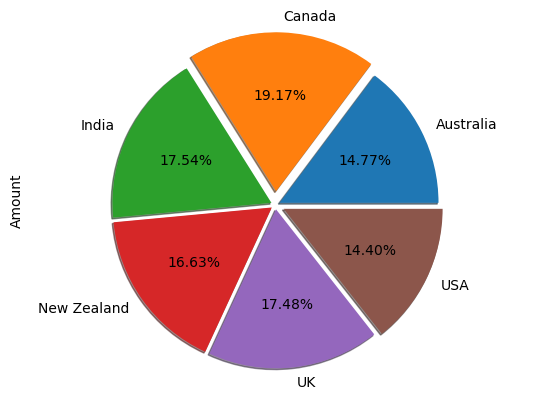

In [88]:
x.groupby('Geography')['Amount'].mean().plot(kind='pie',autopct='%0.2f%%',radius=3.5,shadow=True,explode=[0.1,0.3,0.1,0.1,0.1,0.2])
plt.axis('equal')
plt.show()


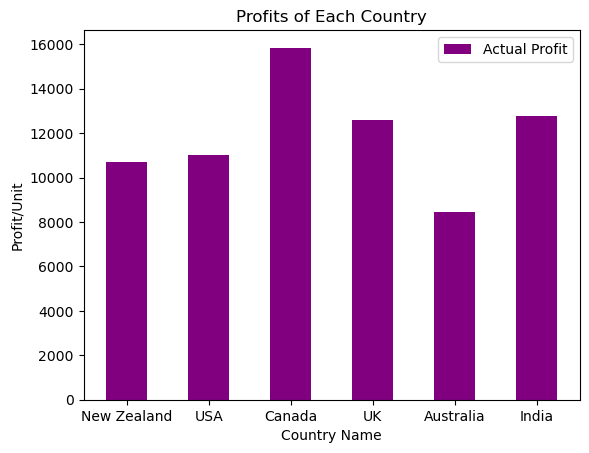

In [81]:
plt.bar(x['Geography'],x['Actual Profit'],width=0.5,label='Actual Profit',color='Purple')
plt.xlabel("Country Name")
plt.ylabel("Profit/Unit")
plt.title("Profits of Each Country")
plt.legend() 

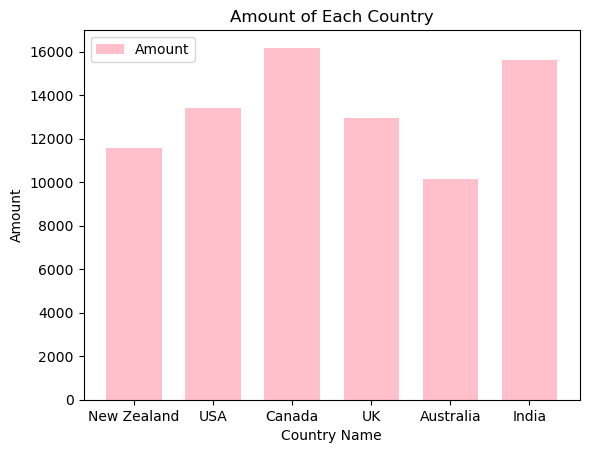

In [83]:
plt.bar(x['Geography'],x['Amount'],width=0.7,label='Amount',color='Pink')
plt.xlabel("Country Name")
plt.ylabel("Amount")
plt.title("Amount of Each Country")
plt.legend()

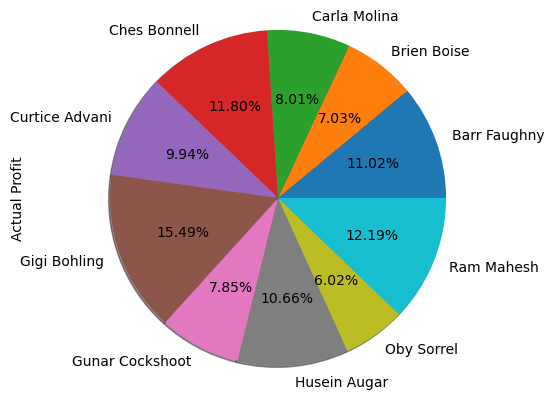

In [87]:
x.groupby('Sales Person') ['Actual Profit'].sum().plot(kind='pie',autopct='%0.2f%%',radius=3.5,shadow=True)
plt.axis('equal')
plt.show()